# Analysis 2 — Cohort Retention & Churn Prediction

**Business question.** Who is leaving, early enough to act — and how do we *prove* a win-back actually worked?

> Implementation: [`src/churn/`](../src/churn) (cohort, churn model, experiment design).

## Step 1 — Cohort retention
Members grouped by first-purchase month; % still active each subsequent month.

Month 1: 20.2% | Month 3: 19.1% | Month 6: 13.6%


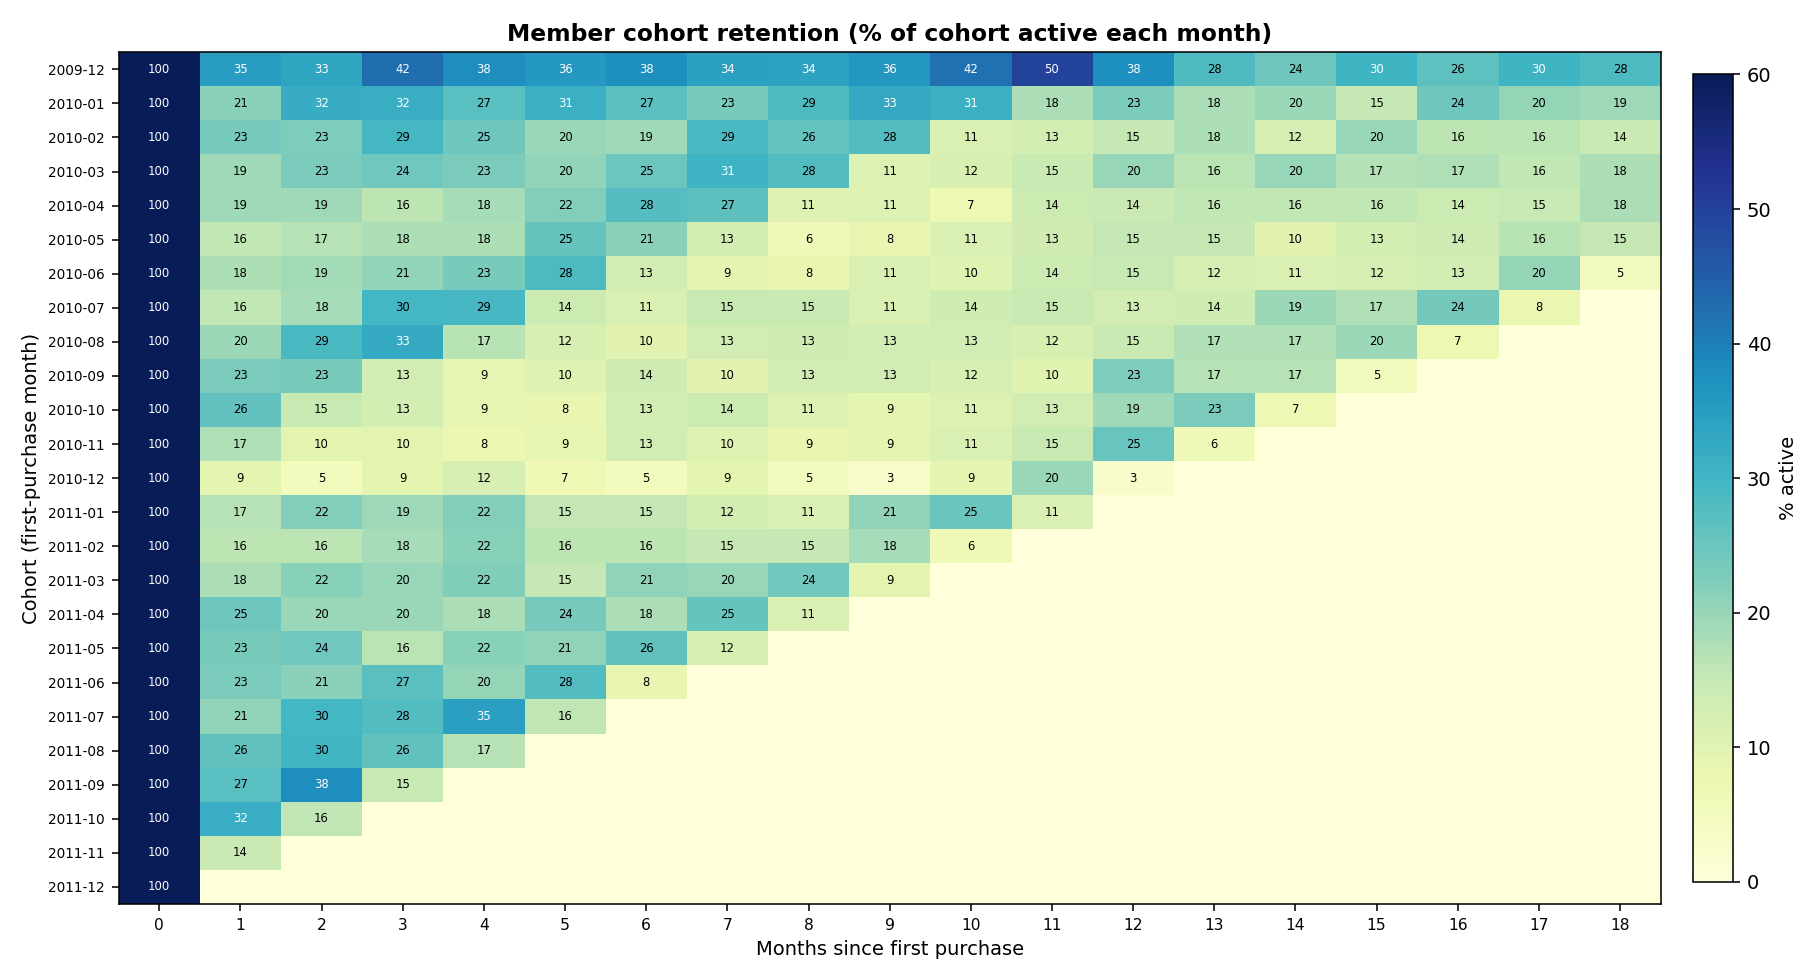

In [1]:
from IPython.display import Image
Image("../reports/figures/cohort_retention_heatmap.png")

The steep month-0→1 drop means the leak is the **second purchase** — fix with onboarding, not loyalty tiers. The decay rate also feeds CLV.

## Step 2 — Churn model (leakage-safe time split)
Features use only data ≤ cutoff; the label is 'no purchase in the next 90 days'. We compare Logistic Regression vs XGBoost on **ROC-AUC**.

In [2]:
from src.churn.churn_model import main
main()

Base churn rate: 56.4%
AUC  Logistic=0.794   XGBoost=0.787
Top churn drivers (gain): recency_days, cadence_days, monetary


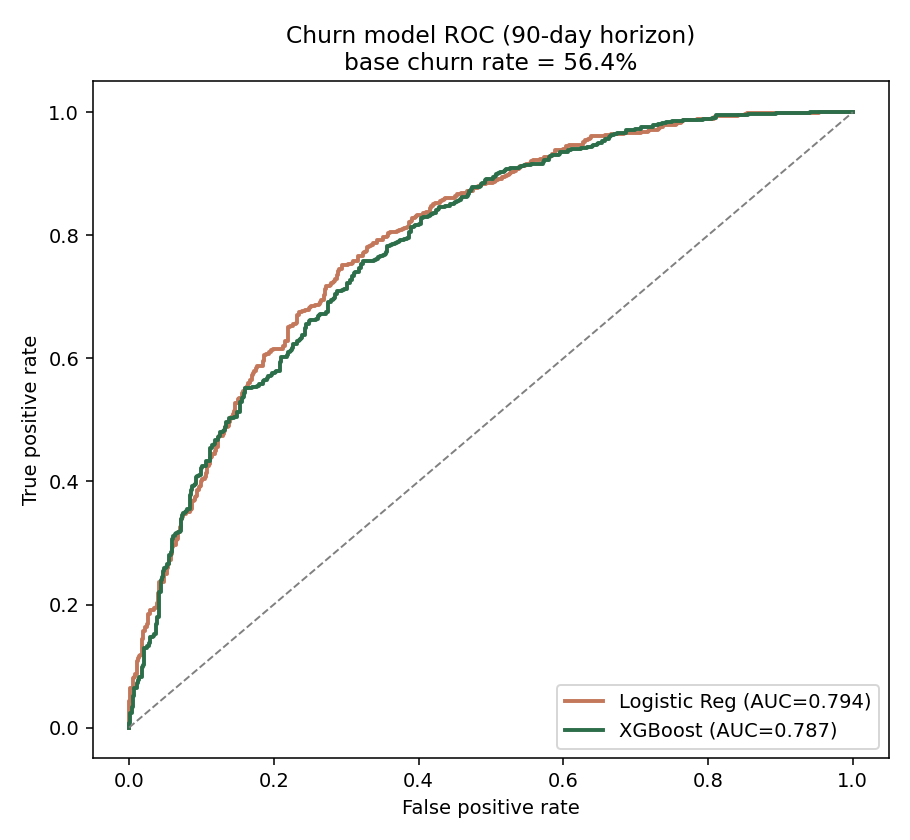

In [3]:
Image("../reports/figures/churn_roc.png")

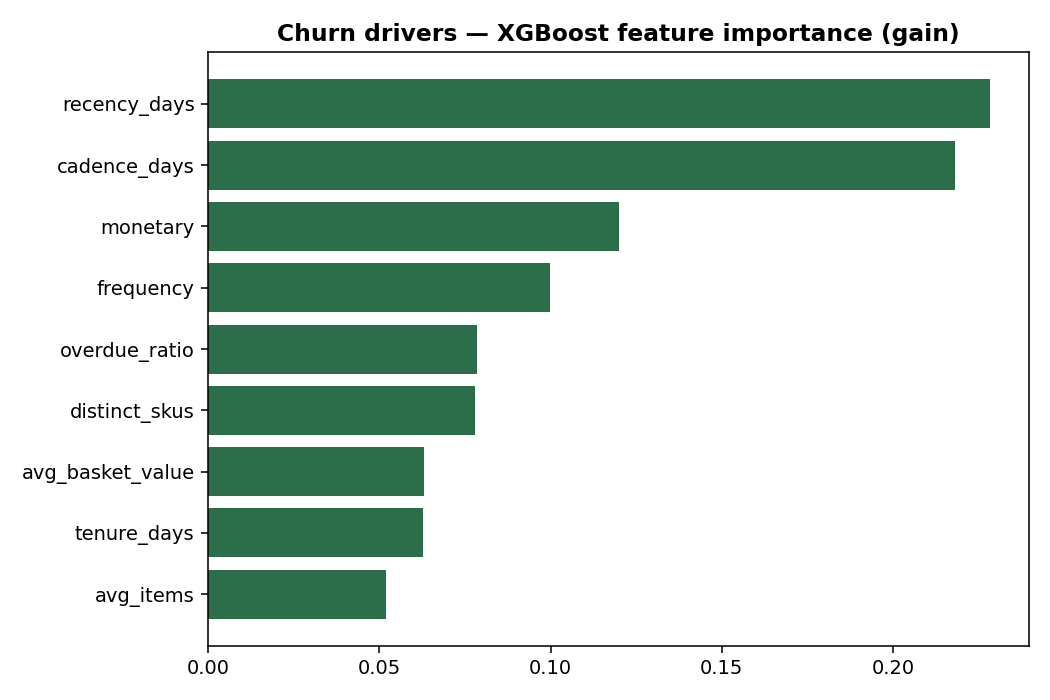

In [4]:
Image("../reports/figures/churn_feature_importance.png")

Logistic ≈ XGBoost (~0.79) — the signal is largely linear, and we report that honestly. **Recency and cadence dominate** ('how far past their normal rhythm are they').

## Step 3 — Win-back experiment design (honest about power)
The rescue cohort is small (n=250), so a randomised A/B with an **untreated control** can only detect a *large* effect (MDE ≈ +13pp at 80% power). We read it directionally or expand the treated population using the churn scores. See [`docs/experiment_design.md`](../docs/experiment_design.md).

## Takeaway
The churn scores prioritise the Rescue list; the cohort curve is the retention KPI.